# Importação de Pacotes

In [ ]:
#leitura da base de dados
import pandas as pd
from pathlib import Path
import parquet

#modelo preditivo escolhido
import catboost as cb
from catboost import CatBoostClassifier

#validação cruzada
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
import numpy as np

#métricas
import matplotlib
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, classification_report

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer

In [ ]:
def estimadores(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)

    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    roc_auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class='ovr',
        average='weighted'
    )

    ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)

    print(f"""
        Acurácia: {acuracia:.3f}
        Recall (weighted): {recall:.3f}
        F1-score (weighted): {f1:.3f}
        ROC AUC (ovr): {roc_auc:.3f}
        """)

    print(classification_report(y_test, y_pred))

## Leitura DataFrame

In [ ]:
df_erro_simples = pd.read_parquet("erro_medico_tidy_final.parquet")
df = df_erro_simples

### Escolha do Modelo

In [ ]:
modelo= CatBoostClassifier(auto_class_weights='Balanced')

### Escolha dos HiperParâmetros

In [ ]:
parametros = {
    'modelo__iterations': [300],
    'modelo__depth': [4, 6, 8],
    'modelo__learning_rate': [0.05, 0.1],
    'modelo__verbose': [0]
}

In [ ]:
df.head(2)

In [ ]:
df.columns

# Aplicação de Pipelines

## Pipeline Padrão

In [ ]:
lista_X = ['valor_acao','n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
           'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
           'tem_perito', 'tem_denuncia_lide', 'tem_assistente']

X = df[lista_X]

y = df["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


pipeline = Pipeline([
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='f1_macro',
    refit= True,
    cv=5
)

searchCV_pipeline.fit(X_train, y_train)

In [ ]:
estimadores(searchCV_pipeline, X_test, y_test)

## Testando Variações no Pipeline

### stratify=y em train_test_split

In [23]:
lista_X = ['valor_acao','n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
           'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
           'tem_perito', 'tem_denuncia_lide', 'tem_assistente']

X = df[lista_X]

y = df["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22, stratify=y)


pipeline = Pipeline([
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='f1_macro',
    refit= True,
    cv=5
)

searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...'Balanced'))])
,param_distributions,"{'modelo__depth': [4, 6, ...], 'modelo__iterations': [300], 'modelo__learning_rate': [0.05, 0.1], 'modelo__verbose': [0]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



        Acurácia: 0.437
        Recall (weighted): 0.437
        F1-score (weighted): 0.476
        ROC AUC (ovr): 0.545
        
              precision    recall  f1-score   support

    improced       0.71      0.50      0.59       425
 parc_proced       0.22      0.31      0.26       124
      proced       0.12      0.24      0.16        66

    accuracy                           0.44       615
   macro avg       0.35      0.35      0.34       615
weighted avg       0.55      0.44      0.48       615



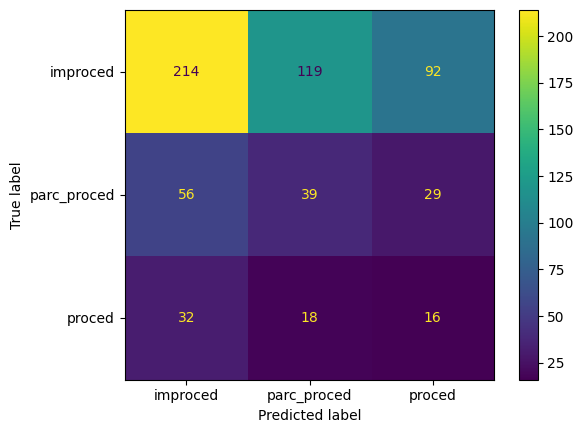

In [24]:
estimadores(searchCV_pipeline, X_test, y_test)